# Lab 2 · Predict, measure, and explain Qwen3 inference

Read [background.md](../background.md) first. This notebook contains the former calculator, GEMM experiment, tutorial, and assessment in one sequence:

1. Configure a GPU roofline and explore its compute/bandwidth limits.
2. Derive decoder FLOPs and estimate Qwen3-8B/32B prefill and decode.
3. Calibrate copy bandwidth and GEMM throughput; freeze held-out predictions.
4. Load real checkpoints, check cached logits, and benchmark a batch-size × context-length grid.
5. Compare prefill/decode latency and token throughput, then use the roofline to explain residuals.

Start Jupyter from the course checkout: `jupyter lab chapters/02_performance_model/code/lab.ipynb` after the [shared setup](../../../shared/SETUP.md). The formulas and plots run without a GPU. Set `RUN_GPU = True` for calibration and `RUN_MODELS = True` for real checkpoint timing. Those paths require CUDA; there is no CPU timing substitute. Prerequisite: Chapter 1’s RMSNorm, RoPE, GQA, SwiGLU, checkpoint mapping, and cached forward implementation. [model.py](model.py) exports its tagged definitions from [Lab 1](../../01_reconstruct_qwen3/code/lab.ipynb), without running lab actions or requiring a live earlier kernel. This chapter adds reusable FLOP/traffic estimators and model benchmark functions around that same implementation.

The default compute ceiling is an **assumption for exploration**, not a published GB10 BF16 specification. Replace it with a documented dense peak for your GPU when interpreting theoretical latency bounds. Latency and token throughput use measured time directly and do not depend on an assumed peak. A measured GEMM ceiling is reported separately.

In [1]:
from dataclasses import asdict, dataclass
from pathlib import Path
import csv
import gc
import hashlib
import json
import math
import platform
import statistics
import subprocess
import time

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').is_file())
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
NOTEBOOK = ROOT / 'chapters/02_performance_model/code/lab.ipynb'

def table(rows):
    if not rows:
        return
    names = list(rows[0])
    display(Markdown('| ' + ' | '.join(names) + ' |\n| ' + ' | '.join(['---'] * len(names)) + ' |\n' +
                     '\n'.join('| ' + ' | '.join(str(row[k]) for k in names) + ' |' for row in rows)))

In [2]:
RUN_GPU = True 
RUN_MODELS = True
DEVICE = 'cuda:0'
DTYPE_NAME = 'bfloat16'                 # Benchmark supports bfloat16 or float16.
REPEATS = 3
WARMUP_RUNS = 2
DECODE_STEPS = 8                       # Eight decode calls => nine generated tokens including prefill's token.
MODEL_KEYS = ['8b', '32b']             # Loaded and released sequentially.
BATCH_SIZES = [1, 2, 4]
CONTEXT_LENGTHS = [128, 512, 2048]      # Prompt tokens per sequence; initial decode cache length.
CASES = [(batch, context) for batch in BATCH_SIZES for context in CONTEXT_LENGTHS]
ATTENTION_BACKEND = 'eager'            # Chapter 1 dense reference; no SDPA dispatch.
# Local Chapter 1 snapshots are used automatically when present; otherwise pinned Hub weights download.
LOCAL_MODEL_PATHS = {}
# This directory must be new: predictions and observations from earlier runs are preserved.
RUN_DIR = ROOT / 'results' / ('p02-' + time.strftime('%Y%m%d-%H%M%S'))

## 1. Build the hardware roofline

$P(\mathrm{AI})=\min(C,\beta\,\mathrm{AI})$, $\mathrm{AI}=F/Q$, and the ridge is $\mathrm{AI}_*=C/\beta$.
The horizontal axis is FLOP/byte and the vertical axis is TFLOP/s. Inputs use decimal TFLOP/s and GB/s. Keep **precision, density, and provenance** beside every compute number. Editing bandwidth changes the slope; editing compute changes the horizontal ceiling.

DGX Spark advertises [273 GB/s memory bandwidth and FP4 AI throughput](https://www.nvidia.com/en-us/products/workstations/dgx-spark/). Its FP4 number is not a BF16 compute ceiling. The 125 TFLOP/s entry below is an explicit teaching assumption, not a conversion of that claim. You can add other precision ceilings, but do not use a precision unless the benchmark actually runs it.

In [3]:
from shared.performance import Hardware, roofline_ms, gemm


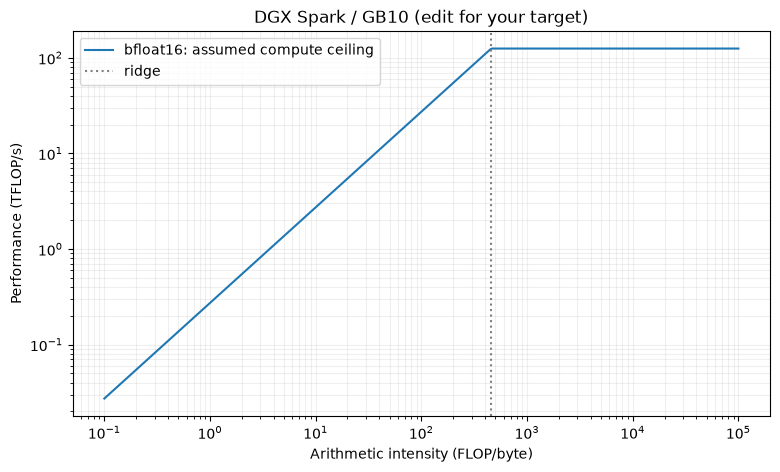

Ridge: 457.9 FLOP/byte


In [4]:
hardware = Hardware(
    name='DGX Spark / GB10 (edit for your target)',
    bandwidth_gbps=273,
    dense_peak_tflops={'bfloat16': 125.0, 'float16': 125.0},
    compute_basis='assumed',
    compute_source='Teaching assumption; replace with documented dense throughput for the selected dtype.',
    bandwidth_source='https://www.nvidia.com/en-us/products/workstations/dgx-spark/',
)
peak = hardware.peak(DTYPE_NAME)
intensities = np.logspace(-1, 5, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(intensities, hardware.ceiling(intensities, DTYPE_NAME), label=f'{DTYPE_NAME}: {hardware.compute_basis} compute ceiling')
ax.axvline(peak * 1000 / hardware.bandwidth_gbps, ls=':', color='gray', label='ridge')
ax.set(xlabel='Arithmetic intensity (FLOP/byte)', ylabel='Performance (TFLOP/s)', title=hardware.name)
ax.grid(True, which='both', alpha=.2)
ax.legend()
plt.show()
print(f'Ridge: {peak * 1000 / hardware.bandwidth_gbps:.1f} FLOP/byte')

**Try it:** double bandwidth, then compute. Predict the change for $\mathrm{AI}=1$ and $\mathrm{AI}=1000$ before rerunning. Why can a decode workload approach its bandwidth limit while remaining far below the compute ceiling?

## 2. Count decoder work from dimensions

Let $B$ be batch, $T$ new tokens per sequence, $P$ cached prefix tokens, $M=BT$, and $A=B(PT+T(T+1)/2)$ valid causal pairs. Prefill uses $(T,P)=(S,0)$; one decode call uses $(1,S)$ and attends **$S+1$** positions. The first generated token comes from prefill logits.

The function below exposes every matmul. GQA reduces K/V widths, but attention still uses all query heads. Qwen3-32B has $H_qR=8192\ne D=5120$. `attention_count='dense'` counts the full $BT(P+T)$ rectangle as a comparison; our roofline diagnostic uses useful causal matmul FLOPs. Norms, softmax, RoPE, activations, residuals and token selection execute, but are excluded from this dominant-matmul numerator. Their lower-order equations are in the background operator table.

The checkpoint revisions below pin the [8B config](https://huggingface.co/Qwen/Qwen3-8B/blob/b968826d9c46dd6066d109eabc6255188de91218/config.json) and [32B config](https://huggingface.co/Qwen/Qwen3-32B/blob/9216db5781bf21249d130ec9da846c4624c16137/config.json).

In [ ]:
from shared.performance import ModelDimensions, MODELS, REVISIONS, REPOS, decoder_layer_flops, model_work, metrics, predict_tradeoffs


In [6]:
table([dict(model=name, **asdict(c), parameters=f'{c.parameters:,}') for name, c in MODELS.items()])
ledger = []
for op in decoder_layer_flops(MODELS['8b'], 1, 1, 2048):
    ledger.append(dict(operator=op, **{name: f'{decoder_layer_flops(c, 1, 1, 2048)[op]:,}' for name, c in MODELS.items()}))
table(ledger)
print('Per-layer FLOPs: B=1, one decode token after a 2048-token prefix (2049 attended positions).')

estimates = []
for name, c in MODELS.items():
    for phase, t, p in [('prefill', 2048, 0), ('decode', 1, 2048)]:
        w = model_work(c, 1, t, p)
        estimates.append(dict(model=name, phase=phase, GFLOPs=round(w['flops']/1e9, 4),
            proxy_GB=round(w['bytes_proxy']/1e9, 4), intensity=round(w['intensity'], 2),
            ideal_bound_ms=round(roofline_ms(w['flops'], w['bytes_proxy'], peak, hardware.bandwidth_gbps), 3)))
table(estimates)

| model | layers | hidden | intermediate | query_heads | kv_heads | head_dim | vocab | parameters |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 8b | 36 | 4096 | 12288 | 32 | 8 | 128 | 151936 | 8,190,735,360 |
| 32b | 64 | 5120 | 25600 | 64 | 8 | 128 | 151936 | 32,762,123,264 |

| operator | 8b | 32b |
| --- | --- | --- |
| q_proj | 33,554,432 | 83,886,080 |
| k_proj | 8,388,608 | 10,485,760 |
| v_proj | 8,388,608 | 10,485,760 |
| qk | 16,785,408 | 33,570,816 |
| av | 16,785,408 | 33,570,816 |
| o_proj | 33,554,432 | 83,886,080 |
| gate_proj | 100,663,296 | 262,144,000 |
| up_proj | 100,663,296 | 262,144,000 |
| down_proj | 100,663,296 | 262,144,000 |

Per-layer FLOPs: B=1, one decode token after a 2048-token prefix (2049 attended positions).


| model | phase | GFLOPs | proxy_GB | intensity | ideal_bound_ms |
| --- | --- | --- | --- | --- | --- |
| 8b | prefill | 29688.6626 | 15.4727 | 1918.78 | 237.509 |
| 8b | decode | 16.3447 | 15.4393 | 1.06 | 56.554 |
| 32b | prefill | 132219.9765 | 64.5475 | 2048.41 | 1057.76 |
| 32b | decode | 68.2641 | 64.5059 | 1.06 | 236.285 |

**Check by hand:** derive the 32B Q projection using $[M,5120][5120,8192]$. Then change batch, prompt length and `logits_tokens`. Why does `logits_tokens=2048` change scoring cost but not decoder-layer cost? Why does replacing query heads with KV heads undercount attention?

`bytes_proxy` assumes resident weights stream once per call and counts only compulsory data and boundary I/O. It omits intermediate activation traffic, tiled KV rereads, dynamic-cache copying, allocator traffic, and materialized scores. New prefill K/V can feed attention on chip, so their cache writes are counted but an additional compulsory read is not assumed. Consequently $F/Q_{proxy}$ is an **optimistic intensity estimate**, not a measured hardware-counter coordinate. It can place a measured point beyond the proxy roofline; that is a model-assumption diagnostic, not proof of exceeding physical bandwidth.

### 2.1 Predict latency–throughput tradeoffs at a fixed context

Use the [analytical latency/throughput relationships](../background.md#analytical-latencythroughput-tradeoffs) with the same FLOP ledger and compulsory-byte proxy as above. For each batch size, the aggregate roofline gives $\widehat t=\max(F/C,Q/\beta)$ in seconds. The first token comes from prefill; this estimate treats its forward time as an **optimistic local TTFT bound**, omitting token selection, launch/host overhead, queueing, and delivery. Hardware ceilings remain the configured assumptions, and capacity is not checked in this analytical sweep.

Keep $S$ fixed while sweeping $B$ for both course models:

- **Prefill:** x = predicted local TTFT in ms, y = total **input** tok/s, $BS/\widehat t_{prefill}$. The first-token latency belongs to each request; the throughput counts prompt tokens across the whole batch.
- **Decode:** x = **interactivity**, $1/\widehat t_{decode}$ in output tok/s per user; y = total **output** throughput, $B/\widehat t_{decode}=B\times\text{interactivity}$. Every active user gets one token per step. This is one step with $S$ cached tokens **before** appending, attending to $S+1$ positions; it is not an average over a growing cache.

The wider analytical batch sweep is independent of the smaller real-model benchmark grid. Every plotted point is annotated with its batch size. Lines connect predicted batches for a model; they are not measured curves. Input and output throughput count different work and should not be compared as equivalent rates.


In [7]:
PREDICTION_CONTEXT = 2048             # Fixed prompt length / decode prefix tokens per sequence.
PREDICTION_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64]

tradeoff_predictions = [dict(model=key, **row)
    for key in MODEL_KEYS
    for row in predict_tradeoffs(MODELS[key], PREDICTION_BATCH_SIZES,
                                PREDICTION_CONTEXT, hardware, DTYPE_NAME)]
columns = ['model', 'phase', 'batch', 'context', 'latency_ms', 'token_kind',
           'total_tokens_per_second', 'interactivity_tokens_per_second', 'limiting_term']
table([{k: round(row[k], 3) if isinstance(row[k], float) else row[k] for k in columns}
       for row in tradeoff_predictions])


| model | phase | batch | context | latency_ms | token_kind | total_tokens_per_second | interactivity_tokens_per_second | limiting_term |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 8b | prefill | 1 | 2048 | 237.509 | input | 8622.82 | None | compute |
| 8b | decode | 1 | 2048 | 56.554 | output | 17.682 | 17.682 | memory |
| 8b | prefill | 2 | 2048 | 475.019 | input | 8622.82 | None | compute |
| 8b | decode | 2 | 2048 | 57.662 | output | 34.685 | 17.342 | memory |
| 8b | prefill | 4 | 2048 | 950.037 | input | 8622.82 | None | compute |
| 8b | decode | 4 | 2048 | 59.878 | output | 66.803 | 16.701 | memory |
| 8b | prefill | 8 | 2048 | 1900.074 | input | 8622.82 | None | compute |
| 8b | decode | 8 | 2048 | 64.309 | output | 124.399 | 15.55 | memory |
| 8b | prefill | 16 | 2048 | 3800.149 | input | 8622.82 | None | compute |
| 8b | decode | 16 | 2048 | 73.173 | output | 218.661 | 13.666 | memory |
| 8b | prefill | 32 | 2048 | 7600.298 | input | 8622.82 | None | compute |
| 8b | decode | 32 | 2048 | 90.899 | output | 352.039 | 11.001 | memory |
| 8b | prefill | 64 | 2048 | 15200.595 | input | 8622.82 | None | compute |
| 8b | decode | 64 | 2048 | 126.352 | output | 506.521 | 7.914 | memory |
| 32b | prefill | 1 | 2048 | 1057.76 | input | 1936.167 | None | compute |
| 32b | decode | 1 | 2048 | 236.285 | output | 4.232 | 4.232 | memory |
| 32b | prefill | 2 | 2048 | 2115.52 | input | 1936.167 | None | compute |
| 32b | decode | 2 | 2048 | 238.254 | output | 8.394 | 4.197 | memory |
| 32b | prefill | 4 | 2048 | 4231.039 | input | 1936.167 | None | compute |
| 32b | decode | 4 | 2048 | 242.191 | output | 16.516 | 4.129 | memory |
| 32b | prefill | 8 | 2048 | 8462.078 | input | 1936.167 | None | compute |
| 32b | decode | 8 | 2048 | 250.066 | output | 31.992 | 3.999 | memory |
| 32b | prefill | 16 | 2048 | 16924.157 | input | 1936.167 | None | compute |
| 32b | decode | 16 | 2048 | 265.816 | output | 60.192 | 3.762 | memory |
| 32b | prefill | 32 | 2048 | 33848.314 | input | 1936.167 | None | compute |
| 32b | decode | 32 | 2048 | 297.315 | output | 107.63 | 3.363 | memory |
| 32b | prefill | 64 | 2048 | 67696.628 | input | 1936.167 | None | compute |
| 32b | decode | 64 | 2048 | 360.314 | output | 177.623 | 2.775 | memory |

In [8]:
from shared.performance import plot_tradeoffs


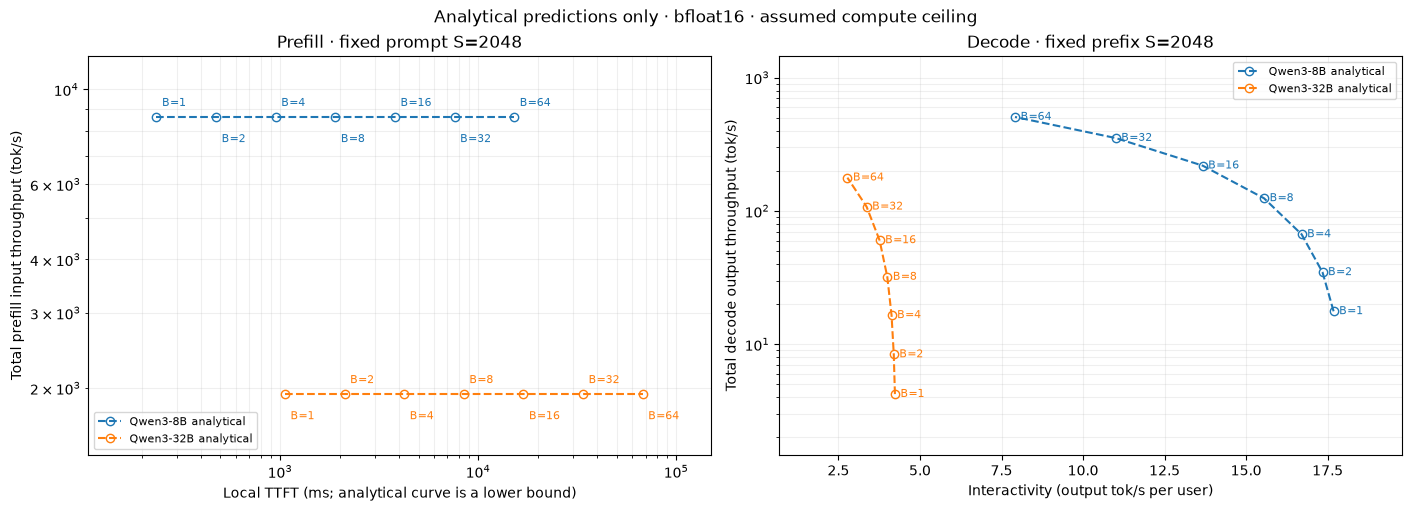

In [9]:
tradeoff_fig, tradeoff_axes = plot_tradeoffs(
    tradeoff_predictions, PREDICTION_CONTEXT, DTYPE_NAME, hardware.compute_basis)
plt.show()


**Interpret the curves:** at fixed context, why can prefill throughput plateau while TTFT grows with batch? Why can decode throughput rise while interactivity falls? Locate the change between memory and compute limits using the table. Then change only `PREDICTION_CONTEXT`, predict how both curves move, and rerun. Preserve the baseline predictions before a matched real-model comparison; do not interpret an analytically attractive batch as proof that its weights, KV, and attention workspace fit in memory.


## 3. Calibrate hardware and freeze six GEMM predictions

Use host-to-device copy buffers larger than last-level cache, counting both read and write. GEMM outputs are preallocated. Warmup and allocation are outside the CUDA-event region. Copy bandwidth and GEMM throughput are empirical ceilings for these shapes, not manufacturer peaks. Repeated small GEMMs may reuse cached weights.

The small-call floor is an observed workload interval including possible dispatch gaps, not a pure launch latency. Freeze calibration at $M=1,16,512$ and save six predictions before measuring $M=2,4,8,32,64,128$. A single effective rate is deliberately simple; its errors motivate shape-specific calibration.

In [10]:
from shared.performance import require_cuda, cuda_samples, write_json, write_csv, calibrate


In [11]:
calibration, gemm_rows = None, []
model_rows, model_status, loaded_metadata = [], [], []
if RUN_MODELS and not RUN_GPU:
    raise ValueError('Enable RUN_GPU before running model benchmarks.')
if RUN_GPU:
    torch = require_cuda(DEVICE, DTYPE_NAME)
    RUN_DIR.mkdir(parents=True, exist_ok=False)
    manifest = dict(hardware=asdict(hardware), precision=DTYPE_NAME, gpu=torch.cuda.get_device_name(DEVICE),
        cuda=torch.version.cuda, torch=torch.__version__, python=platform.python_version(),
        device=DEVICE, repeats=REPEATS, warmup_runs=WARMUP_RUNS, decode_steps=DECODE_STEPS,
        batch_sizes=BATCH_SIZES, context_lengths=CONTEXT_LENGTHS, cases=CASES,
        throughput='prefill input tokens / prefill wall seconds; decode output tokens / decode wall seconds',
        attention_backend=ATTENTION_BACKEND, cache='per-layer (K,V) tensors; torch.cat append',
        attention_matmul_precision='float32', tf32=False,
        model_revisions=REVISIONS, compute_count='causal matmuls, final-position logits',
        bytes='compulsory-data proxy; not measured DRAM traffic',
        timing='CUDA forward intervals; synchronized wall time through greedy token ready',
        notebook_sha256=hashlib.sha256(NOTEBOOK.read_bytes()).hexdigest())
    write_json(RUN_DIR/'manifest.json', manifest)
    write_json(RUN_DIR/'analytical_tradeoffs.json', dict(
        result_kind='analytical prediction; not measured', hardware=asdict(hardware), precision=DTYPE_NAME,
        context=PREDICTION_CONTEXT, batches=PREDICTION_BATCH_SIZES, model_revisions=REVISIONS,
        points=tradeoff_predictions))
    for extension in ['svg', 'png']:
        tradeoff_fig.savefig(RUN_DIR/f'analytical_tradeoffs.{extension}', bbox_inches='tight')
    calibration, gemm_rows = calibrate(DEVICE, DTYPE_NAME, REPEATS, RUN_DIR)
    print(calibration)
else:
    print('Analytical mode: GPU calibration and model timing are unmeasured.')

{'effective_tflops': 73.5510105312599, 'copy_gbps': 220.19482341320742, 'small_call_floor_ms': 0.006483839750289917, 'predicted_gemm_ms': {2: 0.15901785249123349, 4: 0.15916666616220024, 8: 0.1594642935041338, 32: 0.16125005755573507, 64: 0.16363107629120346, 128: 0.16839311376214022}, 'copy_buffer_bytes': 268435456}


| m | measured_ms | predicted_ms | relative_error |
| --- | --- | --- | --- |
| 2 | 0.12238080501556396 | 0.15901785249123349 | 0.2993692309101101 |
| 4 | 0.1349792003631592 | 0.15916666616220024 | 0.1791940219972047 |
| 8 | 0.13968319892883302 | 0.1594642935041338 | 0.141613985983948 |
| 32 | 0.13684159517288208 | 0.16125005755573507 | 0.17837019768745008 |
| 64 | 0.13229119777679443 | 0.16363107629120346 | 0.2369007087477323 |
| 128 | 0.14955199956893922 | 0.16839311376214022 | 0.12598369963295467 |

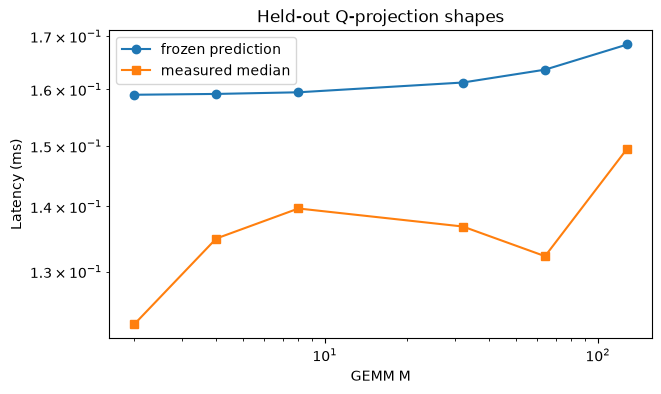

In [12]:
if gemm_rows:
    gemm_summary = []
    for m in sorted({r['m'] for r in gemm_rows}):
        group = [r for r in gemm_rows if r['m'] == m]
        measured = statistics.median(r['cuda_ms'] for r in group)
        predicted = group[0]['predicted_ms']
        gemm_summary.append(dict(m=m, measured_ms=measured, predicted_ms=predicted,
                                 relative_error=abs(predicted-measured)/measured))
    table(gemm_summary)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.loglog([r['m'] for r in gemm_summary], [r['predicted_ms'] for r in gemm_summary], 'o-', label='frozen prediction')
    ax.loglog([r['m'] for r in gemm_summary], [r['measured_ms'] for r in gemm_summary], 's-', label='measured median')
    ax.set(xlabel='GEMM M', ylabel='Latency (ms)', title='Held-out Q-projection shapes')
    ax.legend()
    for extension in ['svg', 'png']:
        fig.savefig(RUN_DIR/f'gemm_prediction.{extension}', bbox_inches='tight')
    plt.show()

## 4. Freeze full-model estimates, then load real Qwen3

The checkpoint paths from Chapter 1 are detected first. Otherwise the loader downloads the pinned repository through `snapshot_download`. For an explicit download, run `hf download Qwen/Qwen3-8B --revision b968826d9c46dd6066d109eabc6255188de91218` or the corresponding 32B repository/revision above. No credentials are needed for these public weights.

BF16 weight storage alone is approximately 16.38 GB (8B) and 65.52 GB (32B), plus cache, activations, load overhead, and runtime memory. Models are loaded one at a time on exactly one GPU without CPU offload. A loading capacity failure leaves the model **unmeasured**. If a larger grid point runs out of memory after loading, record that point as **unmeasured** and continue with the other cases; incomplete repeats never create a summary point. Completed cases are saved after each workload. On unified-memory systems, reclaimable host file cache can make free CUDA memory an overly pessimistic capacity check, so the GB10 preflight uses Linux `MemAvailable`, including reclaimable file cache. Other GPUs use free device memory. The loading preflight adds a working-memory reserve to weights and the smallest case’s KV capacity; this estimate cannot guarantee that every grid point fits, especially with dense score materialization. The Chapter 1 reference exported by `model.py` is initialized on meta, audited, and filled one safetensors shard at a time using Chapter 1’s strict loader. Transformers is a correctness oracle in the regression tests; the timed model is the course implementation. Closing each shard releases its CPU backing storage before the next opens, bounding staging memory on shared host/device RAM.

`prediction.json` records the original hardware lower bounds and a simple calibrated aggregate estimate **before** real-model runs. The aggregate estimate omits sequential-kernel and host overhead; compare errors without promising it is an accurate latency predictor. To build a stronger model, replace it with a sum of operator bounds using shape-specific rates.

The benchmark uses equal-length synthetic token IDs with real checkpoint weights to control $B,S$. Sweep every pair in `BATCH_SIZES × CONTEXT_LENGTHS` so batch comparisons hold context fixed and context comparisons hold batch fixed. Here $S$ is the prompt length and initial decode cache length; decode call $j=0,1,\ldots$ sees a prefix of $S+j$ tokens and attends to $S+j+1$ positions after appending. Keep `DECODE_STEPS` fixed across the grid. It is a performance workload, not a quality evaluation. Tokenization, download, model load, and prompt construction occur outside timing. Every prefill starts with an empty cache. `decode=True` selects final-position logits and matches the FLOP estimator. A short cached-versus-full-prefix logits check runs before timing. The caller owns the per-layer `(K, V)` cache and retains each returned replacement.

The reference materializes dense attention scores, expands grouped KV heads, and copies the prefix on cache append. QK/AV and softmax execute in FP32 even with BF16/FP16 weights; norms and RoPE also use FP32 intermediates. Predict a larger gap from the ideal bound as score storage and cache-copy traffic grow; compare prompt lengths to test that prediction. These costs are omitted from the compulsory-byte proxy. Preserve `source_sha256` with results and restart the kernel after editing Chapter 1 definitions.

In [13]:
predictions = []
for key in MODEL_KEYS:
    c = MODELS[key]
    for batch, prompt in CASES:
        for phase in ['prefill', 'decode']:
            steps = [0] if phase == 'prefill' else range(DECODE_STEPS)
            for step in steps:
                t, p = (prompt, 0) if phase == 'prefill' else (1, prompt + step)
                work = model_work(c, batch, t, p)
                predicted_ms = roofline_ms(work['flops'], work['bytes_proxy'], peak, hardware.bandwidth_gbps)
                calibrated_ms = (roofline_ms(work['flops'], work['bytes_proxy'], calibration['effective_tflops'], calibration['copy_gbps'])
                                 if calibration else None)
                predictions.append(dict(model=key, batch=batch, prompt=prompt, phase=phase, step=step,
                    prefix_tokens=p, new_tokens=t, **work, ideal_bound_ms=predicted_ms,
                    calibrated_aggregate_ms=calibrated_ms))
if RUN_GPU:
    write_json(RUN_DIR/'prediction.json', predictions)
print(f'{len(predictions)} phase/step estimates frozen; real-model timing has not started.')

162 phase/step estimates frozen; real-model timing has not started.


In [14]:
from shared.performance import resolve_checkpoint, reference_model_module, load_resident_model, check_capacity, load_qwen, check_cached_logits, benchmark_model
import shared.performance as performance
performance.LOCAL_MODEL_PATHS = globals().get('LOCAL_MODEL_PATHS', {})


In [15]:
if RUN_MODELS:
    import transformers
    manifest['transformers'] = transformers.__version__
    for key in MODEL_KEYS:
        model = None
        try:
            model, metadata = load_qwen(key, DEVICE, DTYPE_NAME, ATTENTION_BACKEND, CASES, DECODE_STEPS)
            metadata['cached_logits_max_abs_error'] = check_cached_logits(model, DEVICE)
            loaded_metadata.append(metadata)
            for batch, prompt in CASES:
                try:
                    case_rows = benchmark_model(model, key, [(batch, prompt)], REPEATS,
                                                WARMUP_RUNS, DECODE_STEPS, DEVICE, DTYPE_NAME)
                    model_rows.extend(case_rows)
                    model_status.append(dict(model=key, batch=batch, prompt=prompt, status='measured'))
                except torch.cuda.OutOfMemoryError as error:
                    model_status.append(dict(model=key, batch=batch, prompt=prompt,
                        status='unmeasured: insufficient GPU memory', detail=str(error)))
                finally:
                    gc.collect()
                    torch.cuda.empty_cache()
                    write_csv(RUN_DIR/'results.csv', model_rows)
                    write_json(RUN_DIR/'model_status.json', model_status)
        except torch.cuda.OutOfMemoryError as error:
            model_status.append(dict(model=key, status='unmeasured: insufficient GPU memory', detail=str(error)))
        finally:
            del model
            gc.collect()
            torch.cuda.empty_cache()
            write_csv(RUN_DIR/'results.csv', model_rows)
            write_json(RUN_DIR/'model_status.json', model_status)
            manifest['loaded_models'] = loaded_metadata
            write_json(RUN_DIR/'manifest.json', manifest)
    table(model_status)
else:
    print('Real checkpoints unmeasured. Set RUN_GPU and RUN_MODELS to True, then run from the configuration cell.')

/home/huangruoyu/workspace/inference-engineer-study-hall/courses/llm-inference-performance-modeling/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading 8b from /home/huangruoyu/workspace/inference-engineer-study-hall/courses/llm-inference-performance-modeling/models/qwen3-8b/b968826d9c46dd6066d109eabc6255188de91218; CUDA free/total GB: [55.67, 128.52]
Loading 32b from /home/huangruoyu/workspace/inference-engineer-study-hall/courses/llm-inference-performance-modeling/models/qwen3-32b/9216db5781bf21249d130ec9da846c4624c16137; CUDA free/total GB: [39.83, 128.52]


| model | batch | prompt | status |
| --- | --- | --- | --- |
| 8b | 1 | 128 | measured |
| 8b | 1 | 512 | measured |
| 8b | 1 | 2048 | measured |
| 8b | 2 | 128 | measured |
| 8b | 2 | 512 | measured |
| 8b | 2 | 2048 | measured |
| 8b | 4 | 128 | measured |
| 8b | 4 | 512 | measured |
| 8b | 4 | 2048 | measured |
| 32b | 1 | 128 | measured |
| 32b | 1 | 512 | measured |
| 32b | 1 | 2048 | measured |
| 32b | 2 | 128 | measured |
| 32b | 2 | 512 | measured |
| 32b | 2 | 2048 | measured |
| 32b | 4 | 128 | measured |
| 32b | 4 | 512 | measured |
| 32b | 4 | 2048 | measured |

## 5. Prefill/decode latency and token throughput

`cuda_ms` measures the forward interval (including device idle gaps within it); `token_ready_ms` measures synchronized wall time through greedy selection. Prefill's wall interval is **local TTFT** from ready device inputs. Decode wall intervals are **local TBT** with synchronization after each token. They exclude request queues, tokenization, network delivery and serving scheduling; they are not server TTFT/TBT or maximum-throughput generation. We generate one first token plus `DECODE_STEPS` subsequent tokens and deliberately continue through EOS to keep work fixed.

For batch $B$, prompt length $S$ per sequence, and $K$ decode calls in one repeat:

| Metric | Calculation | Scope |
|---|---|---|
| Prefill latency | $t_{prefill}$ | One batched prompt forward through first-token selection |
| Prefill throughput | $BS/t_{prefill}$ | **Input** tok/s across the batch; do not count the first output token as a prompt token |
| Mean decode latency | $\sum_{j=1}^{K}t_j/K$ | Mean local TBT per sequence; one token per sequence at each step |
| Decode throughput | $BK/\sum_{j=1}^{K}t_j$ | **Output** tok/s across the batch; excludes prefill and its first output token |

Times in these formulas are seconds. `latency_ms` and `tokens_per_second` below use the synchronized wall intervals. `forward_ms` is retained separately for comparison with the frozen forward estimates. Token throughput is total phase tokens divided by total phase time **within each repeat**, not an average of per-step rates. Larger batch can increase aggregate throughput while also increasing per-request decode latency.

Raw rows retain each prefix length and token count. For each grid point, summarize independent repeats with medians and min/max bars (observed ranges, not confidence intervals). Decode points cover the short growing-cache window beginning at the plotted context, not a cache held at constant length. The roofline is a secondary diagnostic: its achieved FLOP/s uses summed work divided by summed CUDA time, and its intensity uses summed FLOPs divided by summed proxy bytes.


In [16]:
from shared.performance import summarize_model_rows, summarize_tradeoff_observations


In [17]:
summary = summarize_model_rows(model_rows)
if summary:
    display_columns = ['model', 'batch', 'prompt', 'phase', 'latency_ms',
                       'throughput_token_kind', 'tokens_per_second', 'repeats']
    table([{k: (round(r[k], 3) if isinstance(r[k], float) else r[k])
            for k in display_columns} for r in summary])
    for row in summary:
        predicted = [r for r in predictions if (r['model'], r['batch'], r['prompt'], r['phase']) ==
                     (row['model'], row['batch'], row['prompt'], row['phase'])]
        row['ideal_bound_ms'] = statistics.mean(r['ideal_bound_ms'] for r in predicted)
        row['calibrated_aggregate_ms'] = statistics.mean(r['calibrated_aggregate_ms'] for r in predicted)
        row['relative_error'] = abs(row['calibrated_aggregate_ms']-row['forward_ms'])/row['forward_ms']
    write_csv(RUN_DIR/'summary.csv', summary)
    write_json(RUN_DIR/'summary.json', dict(points=summary,
        median_relative_error=statistics.median(r['relative_error'] for r in summary),
        model_status=model_status))
else:
    print('No measured model points: the next chart contains only the configured hardware roofline.')

| model | batch | prompt | phase | latency_ms | throughput_token_kind | tokens_per_second | repeats |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 32b | 1 | 128 | decode | 302.959 | output | 3.301 | 3 |
| 32b | 1 | 128 | prefill | 376.735 | input | 339.761 | 3 |
| 32b | 1 | 512 | decode | 323.797 | output | 3.088 | 3 |
| 32b | 1 | 512 | prefill | 916.037 | input | 558.929 | 3 |
| 32b | 1 | 2048 | decode | 416.947 | output | 2.398 | 3 |
| 32b | 1 | 2048 | prefill | 6674.855 | input | 306.823 | 3 |
| 32b | 2 | 128 | decode | 314.602 | output | 6.357 | 3 |
| 32b | 2 | 128 | prefill | 459.667 | input | 556.925 | 3 |
| 32b | 2 | 512 | decode | 363.188 | output | 5.507 | 3 |
| 32b | 2 | 512 | prefill | 1767.106 | input | 579.479 | 3 |
| 32b | 2 | 2048 | decode | 549.973 | output | 3.637 | 3 |
| 32b | 2 | 2048 | prefill | 12721.735 | input | 321.969 | 3 |
| 32b | 4 | 128 | decode | 329.071 | output | 12.155 | 3 |
| 32b | 4 | 128 | prefill | 718.214 | input | 712.879 | 3 |
| 32b | 4 | 512 | decode | 428.805 | output | 9.328 | 3 |
| 32b | 4 | 512 | prefill | 3629.201 | input | 564.311 | 3 |
| 32b | 4 | 2048 | decode | 795.764 | output | 5.027 | 3 |
| 32b | 4 | 2048 | prefill | 25324.435 | input | 323.482 | 3 |
| 8b | 1 | 128 | decode | 95.071 | output | 10.518 | 3 |
| 8b | 1 | 128 | prefill | 102.373 | input | 1250.326 | 3 |
| 8b | 1 | 512 | decode | 100.06 | output | 9.994 | 3 |
| 8b | 1 | 512 | prefill | 234.36 | input | 2184.677 | 3 |
| 8b | 1 | 2048 | decode | 126.334 | output | 7.916 | 3 |
| 8b | 1 | 2048 | prefill | 1736.625 | input | 1179.299 | 3 |
| 8b | 2 | 128 | decode | 84.052 | output | 23.795 | 3 |
| 8b | 2 | 128 | prefill | 121.801 | input | 2101.792 | 3 |
| 8b | 2 | 512 | decode | 94.398 | output | 21.187 | 3 |
| 8b | 2 | 512 | prefill | 437.946 | input | 2338.186 | 3 |
| 8b | 2 | 2048 | decode | 148.909 | output | 13.431 | 3 |
| 8b | 2 | 2048 | prefill | 3461.254 | input | 1183.386 | 3 |
| 8b | 4 | 128 | decode | 87.336 | output | 45.8 | 3 |
| 8b | 4 | 128 | prefill | 178.816 | input | 2863.272 | 3 |
| 8b | 4 | 512 | decode | 113.932 | output | 35.109 | 3 |
| 8b | 4 | 512 | prefill | 918.694 | input | 2229.25 | 3 |
| 8b | 4 | 2048 | decode | 224.378 | output | 17.827 | 3 |
| 8b | 4 | 2048 | prefill | 6884.014 | input | 1190.003 | 3 |

### 5.1 Overlay measured points on the Section 2 predictions

Use the **same frozen `tradeoff_predictions`** and `PREDICTION_CONTEXT` as Section 2. Dashed curves with open circles are analytical predictions; solid squares are measured repeat medians with min/max bars on both axes. Dotted segments connect matching model/batch pairs to expose the prediction gap. Measurements come only from this run's real-checkpoint `model_rows`, using the recorded hardware, dtype, backend, and model revisions. No synthetic points or historical runs are substituted when measurements are unavailable.

For prefill, select prompts of exactly `PREDICTION_CONTEXT` tokens and plot local TTFT against aggregate input tok/s. For decode, use only the **first decode call** after that prompt, whose prefix is exactly `PREDICTION_CONTEXT`; plot per-user interactivity against aggregate output tok/s. Later decode calls have longer caches, so averaging them would not match Section 2's fixed-prefix prediction. The other Section 5 plots still summarize the full decode window.

Compute throughput within each repeat before taking medians. Decode interactivity and total throughput share the same observations, with total throughput = batch × interactivity; their error bars are correlated observed ranges, not independent confidence intervals. The analytical latency omits selection/host overhead that is included in measured wall time. This boundary difference is part of the gap to explain.

Run Sections 1–4 with `RUN_GPU = RUN_MODELS = True` to populate the overlay. Include `PREDICTION_CONTEXT` in `CONTEXT_LENGTHS`; the default matches at 2,048 tokens for measured batches 1, 2, and 4. Larger analytical batches remain prediction-only until benchmarked. Missing or capacity-limited conditions produce no measured markers.


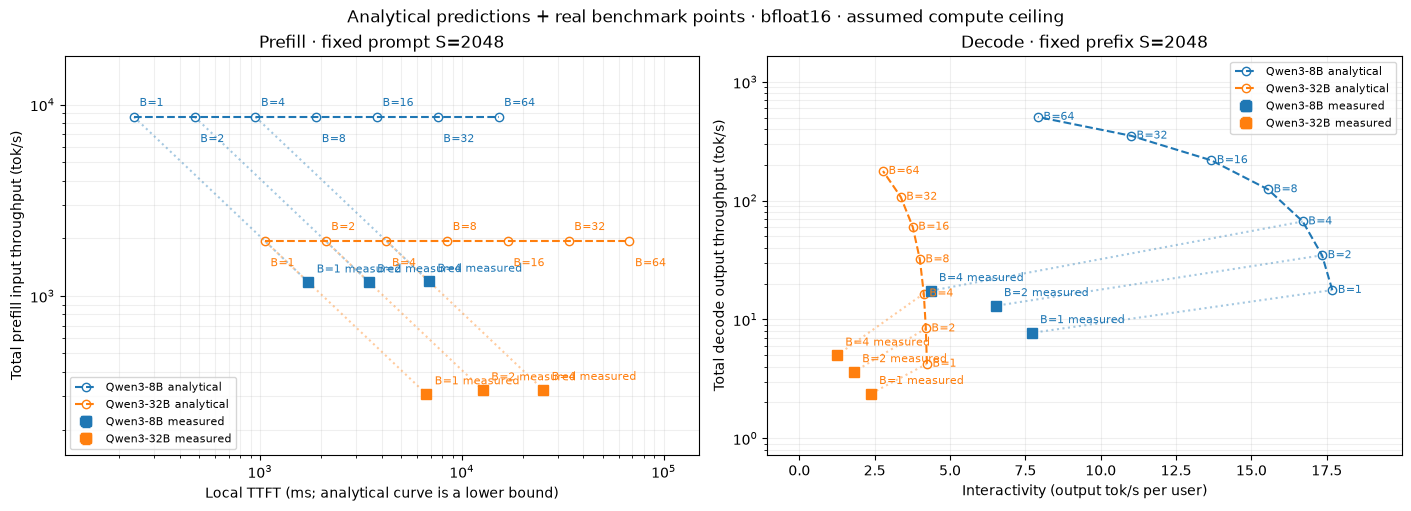

In [18]:
tradeoff_observations = summarize_tradeoff_observations(model_rows, PREDICTION_CONTEXT)
if not tradeoff_observations:
    print(f'No real benchmark points at context {PREDICTION_CONTEXT}; showing predictions only. '
          'Enable RUN_GPU and RUN_MODELS and include this context in the benchmark grid.')
overlay_fig, overlay_axes = plot_tradeoffs(
    tradeoff_predictions, PREDICTION_CONTEXT, DTYPE_NAME, hardware.compute_basis,
    observed=tradeoff_observations)
if RUN_GPU:
    write_csv(RUN_DIR/'tradeoff_observations.csv', tradeoff_observations)
    for extension in ['svg', 'png']:
        overlay_fig.savefig(RUN_DIR/f'analytical_vs_measured_tradeoffs.{extension}', bbox_inches='tight')
plt.show()


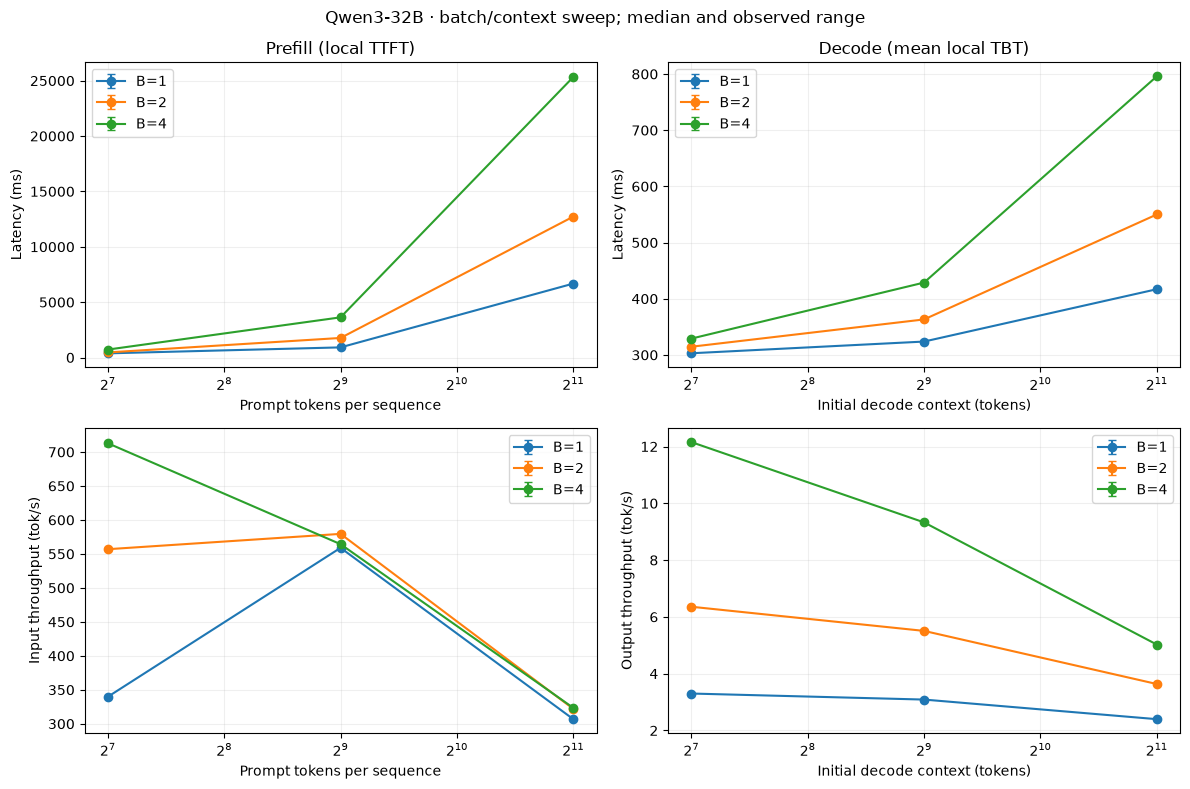

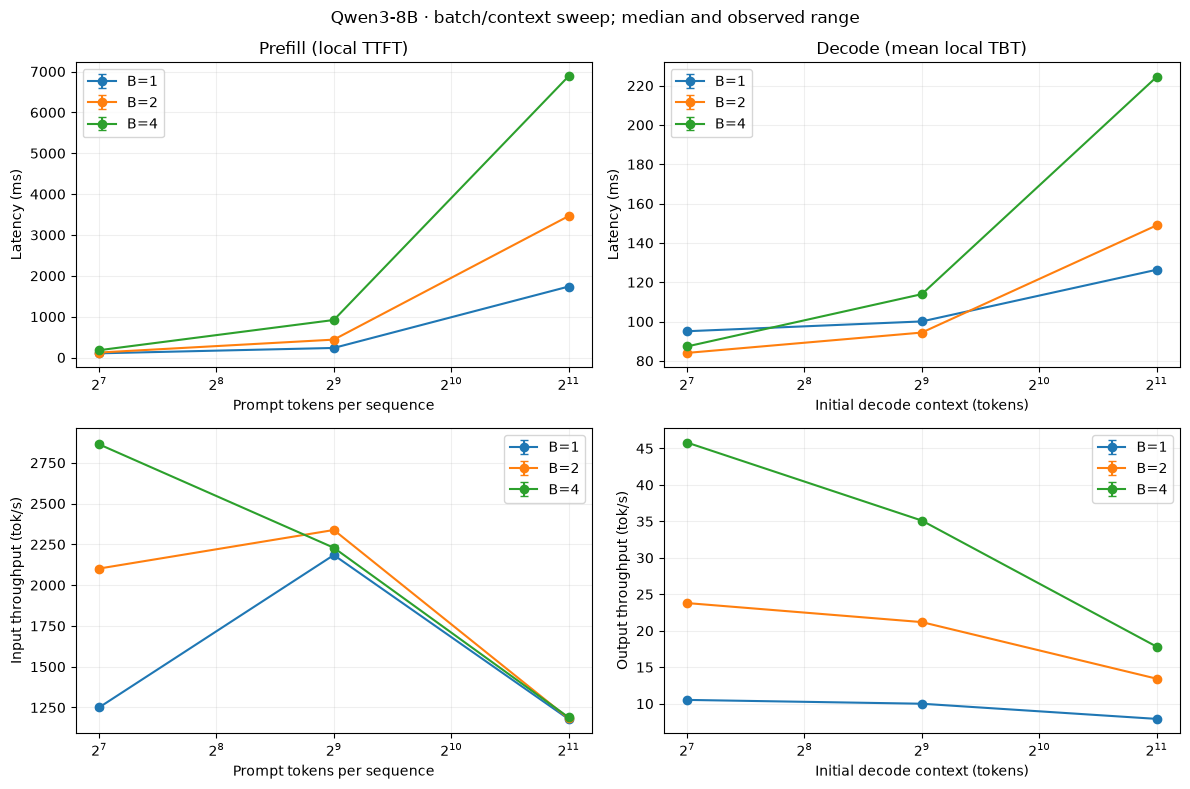

Artifacts: /home/huangruoyu/workspace/inference-engineer-study-hall/courses/llm-inference-performance-modeling/results/p02-20260917-211947


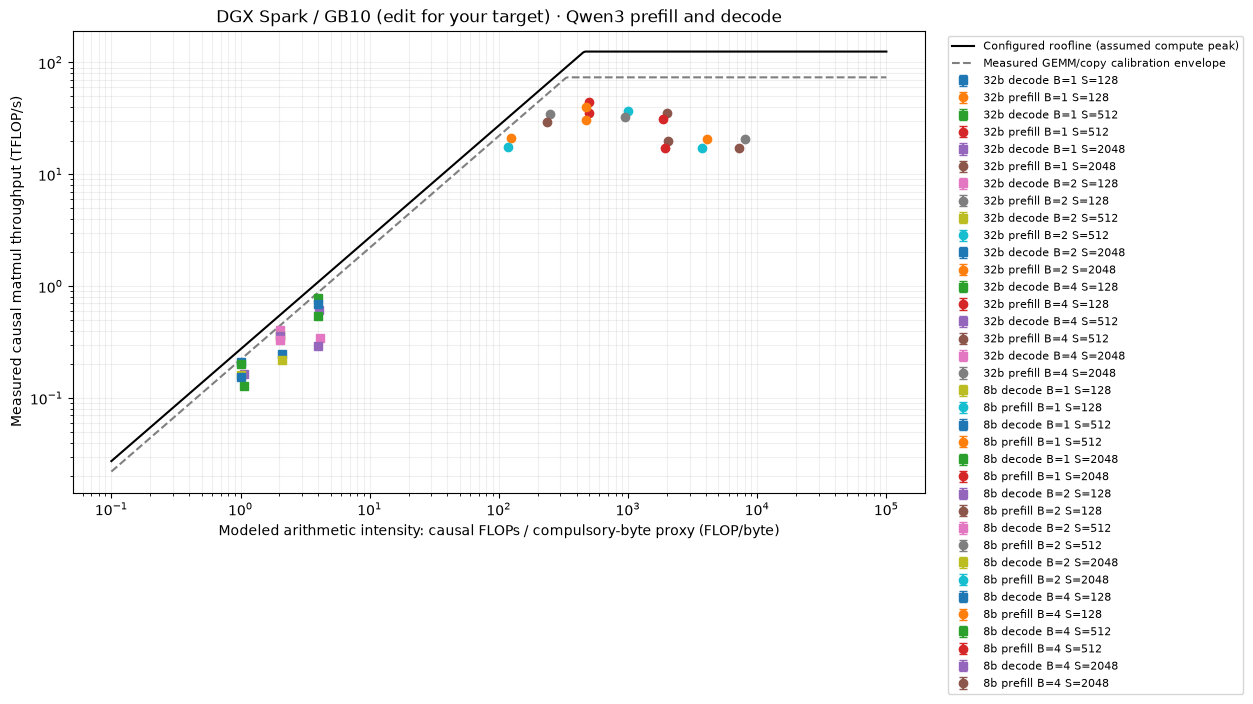

In [19]:
from shared.performance import plot_latency_sweeps, plot_roofline
for key, fig in plot_latency_sweeps(summary).items():
    for extension in ['svg', 'png']:
        fig.savefig(RUN_DIR/f'latency_throughput_{key}.{extension}', bbox_inches='tight')
    display(fig)
    plt.close(fig)
fig, ax = plot_roofline(summary, hardware, DTYPE_NAME, calibration)
if RUN_GPU:
    for extension in ['svg', 'png']:
        fig.savefig(RUN_DIR/f'roofline.{extension}', bbox_inches='tight')
plt.show()


## 6. Explain the measurements and test a prediction

Before changing code, write your answers here:

- Reproduce one operator FLOP count, one prefill input-tok/s value, one decode output-tok/s value, and one plotted intensity from the raw CSV. State the byte and causal-pair assumptions.
- At each fixed context, compare all batch sizes: how do aggregate tok/s and local TBT change? At each fixed batch, compare all context lengths: how do prefill latency, prefill input tok/s, and decode output tok/s scale? Explain throughput/latency tradeoffs without mixing input and output token counts.
- Plot measured forward time against the frozen estimate. Compute $|t_{pred}-t_{measured}|/t_{measured}$ and inspect signed residuals. The 25% median-error target is diagnostic; this compulsory-byte aggregate model may miss it substantially.
- Identify a residual that grows with context, one that grows with batch, or a nearly constant gap. Propose a measurement that separates cache copying, attention rereads, GEMM efficiency, and host dispatch.
- Capture a separate Nsight Systems trace with prefill/decode ranges, then profile a few dominant kernels using Nsight Compute. Profiling/replay times must not replace the ordinary timing rows. Hardware-counter bytes can replace the byte proxy only when measurement scope matches the FLOP/time scope.
- Predict one intervention (larger batch, optimized attention, static cache, or fewer logits positions). Freeze new predictions in a new run directory and test new conditions. Keep the original held-out score.

An aggregate roofline is a ceiling, not a schedule. For serial kernels use $\sum_j\max(F_j/C_j,Q_j/\beta_j)$ plus critical-path overhead. Add shape-specific GEMM calibration and attention measurements before expecting reliable latency predictions.

### Completion evidence

| Milestone | Evidence |
|---|---|
| Theory | Hand derivation of roofline ridge, GQA Q/O shapes, causal prefill and cached decode FLOPs |
| Calibration | Hardware identity/dtype/provenance, raw copy/GEMM repeats, six predictions saved before observations |
| Real models | Cached-logit check; at least three repeats; both 8B and 32B measured in both phases, or explicit capacity-limited unmeasured status |
| Analysis | Raw step contexts/timings and token counts; prefill/decode latency and tok/s curves across batch/context; labeled roofline diagnostic and prediction residuals |
| Full project | A batch × context grid with at least two batch sizes and two context lengths for each model where feasible, both phases, and explicit unmeasured points; trace-supported diagnosis and one tested intervention |

Submit the result directory and a 400–600 word entry note with your original prediction, one reconstructed calculation, and a figure interpretation. For the full project, extend it to a 1,200–2,000 word memo using the [common rubric](../../../shared/REPORT.md). An explained negative result is valid. No synthetic or unperformed run counts as real Qwen timing.

If CUDA is unavailable, complete Sections 1–2 and predictions only. If 32B does not fit, reduce batch/context or use a larger single GPU and retain its separate hardware config. CPU offload, quantization, or tensor parallelism require a different performance model. If cached logits fail the frozen tolerance, resolve the discrepancy before benchmarking. If a result directory exists, choose a new one. With few repeats, min/max bars show observed variation, not confidence intervals.

### Handoff to Chapter 3: select an optimization opportunity

Carry forward one workload’s manifest, frozen theoretical bound and calibrated estimate, raw observed latencies, and a separate profile. Record the signed residual, the suspected mechanism, and evidence that would distinguish it from another cause. Estimate the target operation’s fraction of model time and predict the whole-model benefit of one kernel change, including adapter overhead, using [Chapter 3’s gap analysis](../../03_kernels/background.md#from-chapter-2s-model-to-an-optimization-hypothesis). Keep this prediction before any optimized measurements. A large gap is a hypothesis to investigate, not a guaranteed speedup. Chapter 3 extends the same model exported through `model.py`; Chapter 4 adds the serving runtime afterward.

[Theory and references](../background.md) · [Next: Kernel optimization](../../03_kernels/README.md) · [Course home](../../../README.md)